# Классификация цвета автомобиля. Lab 1 (Colab)

В этой лабораторной решается задача распознавания цвета автомобиля по фронтальному изображению из датасета DVM-CAR. Используется quality-checked subset с фронтальными видами машин. Основная цель — обучить и сравнить три модели классификации и добиться значения `F1_macro > 0.8`.

В работе рассматриваются три подхода:
1. самописная модель `ResNet-18`, реализованная с нуля;
2. предобученная `ResNet50`, дообученная на DVM-CAR;
3. предобученная `MobileNetV3-Large`, также дообученная на этом датасете.

В ноутбуке последовательно показаны:
- подготовка и фильтрация датасета;
- аугментации изображений и их визуальная проверка;
- обучение моделей и сравнение их качества на train/val/test;
- оценка результатов с помощью `F1_macro`;
- подробный анализ через `classification report` и `confusion matrix`;
- демонстрация предсказаний лучшей модели на отдельных изображениях.


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import os, random, math, time, json, shutil, subprocess, sys, tarfile, urllib.request, zipfile
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from IPython.display import display
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
    torch.set_float32_matmul_precision("high")
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

num_workers_default = 0 if device.type == "mps" else max(2, min(8, (os.cpu_count() or 4) // 2))
amp_device = "cuda" if device.type == "cuda" else "cpu"
use_amp_default = device.type == "cuda"
print("device:", device)

SEED = 2


device: cuda


## 2) Загрузка датасета в Colab

Ноутбук скачивает quality-checked subset DVM-CAR напрямую из Figshare и распаковывает его в `/content/dvm_car_data`.


In [ ]:
FIGSHARE_FILE_ID = 34792480
DATA_URL = f"https://ndownloader.figshare.com/files/{FIGSHARE_FILE_ID}"
if Path("/content").exists() and os.access("/content", os.W_OK):
    DATA_DIR = Path("/content/dvm_car_data")
else:
    DATA_DIR = Path.cwd() / "dvm_car_data"
ARCHIVE_PATH = DATA_DIR / "Confirmed_fronts.zip"
EXTRACT_DIR = DATA_DIR / "extracted"
DATA_ROOT = None

def download_file(url: str, dst: Path, chunk_size: int = 1 << 20):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f"Using cached archive: {dst}")
        return dst

    headers = {"User-Agent": "Mozilla/5.0"}
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response, dst.open("wb") as f:
        total = response.headers.get("Content-Length")
        total = int(total) if total is not None else None
        print("Final download URL:", response.geturl())
        print("Content-Type:", response.headers.get("Content-Type"))
        with tqdm(total=total, unit="B", unit_scale=True, desc=f"Downloading {dst.name}") as pbar:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                f.write(chunk)
                pbar.update(len(chunk))

    print(f"Downloaded archive from: {url}")
    return dst

def extract_archive(archive_path: Path, extract_dir: Path):
    marker = extract_dir / ".done"
    if marker.exists():
        print(f"Using extracted dataset: {extract_dir}")
        return extract_dir

    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(archive_path) as zf:
        zf.extractall(extract_dir)

    marker.touch()
    return extract_dir

def resolve_dataset_root(base_dir: Path) -> Path:
    image_exts = {".jpg", ".jpeg", ".png", ".webp"}
    preferred = [base_dir / "confirmed_fronts", base_dir]

    for candidate in preferred:
        if candidate.exists() and any(p.suffix.lower() in image_exts for p in candidate.rglob("*")):
            return candidate

    for candidate in base_dir.rglob("*"):
        if candidate.is_dir() and any(p.suffix.lower() in image_exts for p in candidate.rglob("*")):
            return candidate

    raise FileNotFoundError(f"Could not find a dataset directory with images under: {base_dir}")

download_file(DATA_URL, ARCHIVE_PATH)
extract_archive(ARCHIVE_PATH, EXTRACT_DIR)
DATA_ROOT = resolve_dataset_root(EXTRACT_DIR)
print("DATA_ROOT:", DATA_ROOT)


Using cached archive: /content/dvm_car_data/Confirmed_fronts.zip
DATA_ROOT: /content/dvm_car_data/extracted/confirmed_fronts


## 3) Создание DataFrame

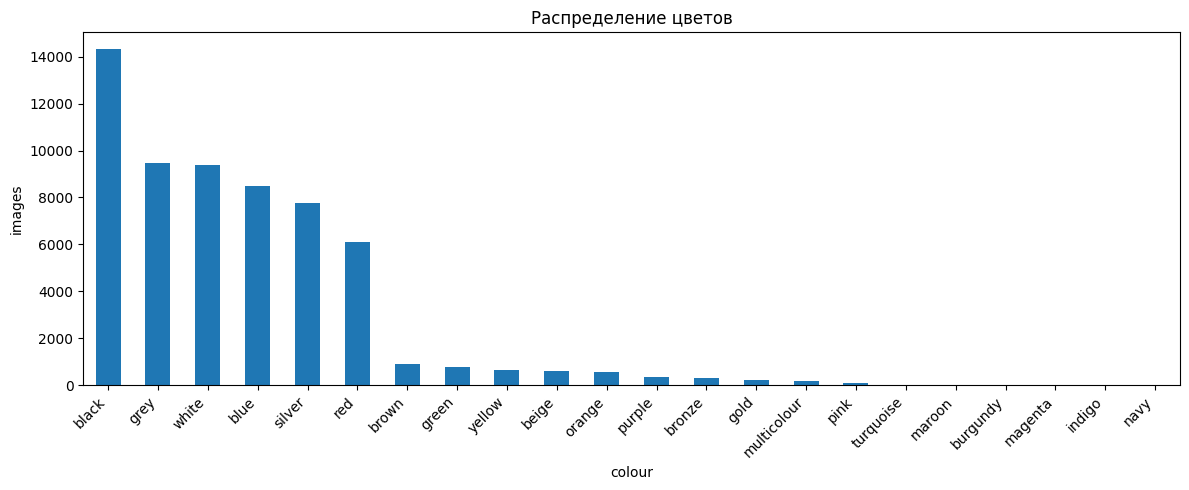

In [ ]:

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

def normalize_colour(value):
    colour = str(value).strip().replace("_", " ").replace("-", " ")
    colour = re.sub(r"\s+", " ", colour)
    return colour.lower()

def is_supported_image(path):
    return path.is_file() and path.suffix.lower() in IMG_EXTS

def split_stem_parts(path):
    stem = path.stem

    if "$$" in stem:
        separator = "$$"
    elif "$" in stem:
        separator = "$"
    else:
        return []

    return [part.strip() for part in stem.split(separator)]

def parse_image_metadata(path):
    parts = split_stem_parts(path)
    brand = model = year = colour = None
    genmodel_id = adv_id = img_idx = None

    if len(parts) >= 4:
        brand, model, year, colour = parts[:4]

    if len(parts) >= 7:
        genmodel_id, adv_id, img_idx = parts[4:7]

    return {
        "path": str(path),
        "brand": brand,
        "model": model,
        "year": year,
        "colour": normalize_colour(colour),
        "genmodel_id": genmodel_id,
        "adv_id": adv_id,
        "img_idx": img_idx,
    }

def should_skip_row(row):
    return row["colour"] == "unlisted"

def finalize_index(rows):
    return (
        pd.DataFrame(rows)
        .dropna(subset=["path", "colour"])
        .drop_duplicates(subset=["path"])
        .reset_index(drop=True)
    )

def build_index(root):
    rows = []

    for path in root.rglob("*"):
        if not is_supported_image(path):
            continue

        row = parse_image_metadata(path)
        if should_skip_row(row):
            continue

        rows.append(row)

    return finalize_index(rows)

df = build_index(DATA_ROOT)

counts = df["colour"].value_counts()

plt.figure(figsize=(12, 5))
counts.plot(kind="bar")
plt.title("Распределение цветов")
plt.ylabel("images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4) Split: train/val/test

In [ ]:

top_colours = df["colour"].value_counts().head(10).index

df_model = df[df["colour"].isin(top_colours)].copy()

colour2id = {colour: idx for idx, colour in enumerate(sorted(df_model["colour"].unique()))}
id2colour = {idx: colour for colour, idx in colour2id.items()}
n_classes = len(colour2id)
df_model["label"] = df_model["colour"].map(colour2id)

train_df, tmp_df = train_test_split(
    df_model, test_size=0.2, random_state=SEED, stratify=df_model["label"]
)

val_df, test_df = train_test_split(
    tmp_df, test_size=0.5, random_state=SEED, stratify=tmp_df["label"]
)

split_summary = pd.DataFrame({
    "label": pd.Series(colour2id),
    "total": df_model["colour"].value_counts(),
    "train": train_df["colour"].value_counts(),
    "val": val_df["colour"].value_counts(),
    "test": test_df["colour"].value_counts(),
}).fillna(0)

split_summary["label"] = split_summary["label"].astype(int)
split_summary[["total", "train", "val", "test"]] = split_summary[["total", "train", "val", "test"]].astype(int)
split_summary = split_summary.sort_values("label")

display(split_summary)


,label,total,train,val,test
beige,0,600,480,60,60
black,1,14317,11453,1432,1432
blue,2,8483,6786,848,849
brown,3,911,729,91,91
green,4,777,622,78,77
grey,5,9474,7579,947,948
red,6,6095,4876,610,609
silver,7,7770,6216,777,777
white,8,9395,7516,940,939
yellow,9,667,534,66,67


## 5) Аугментации

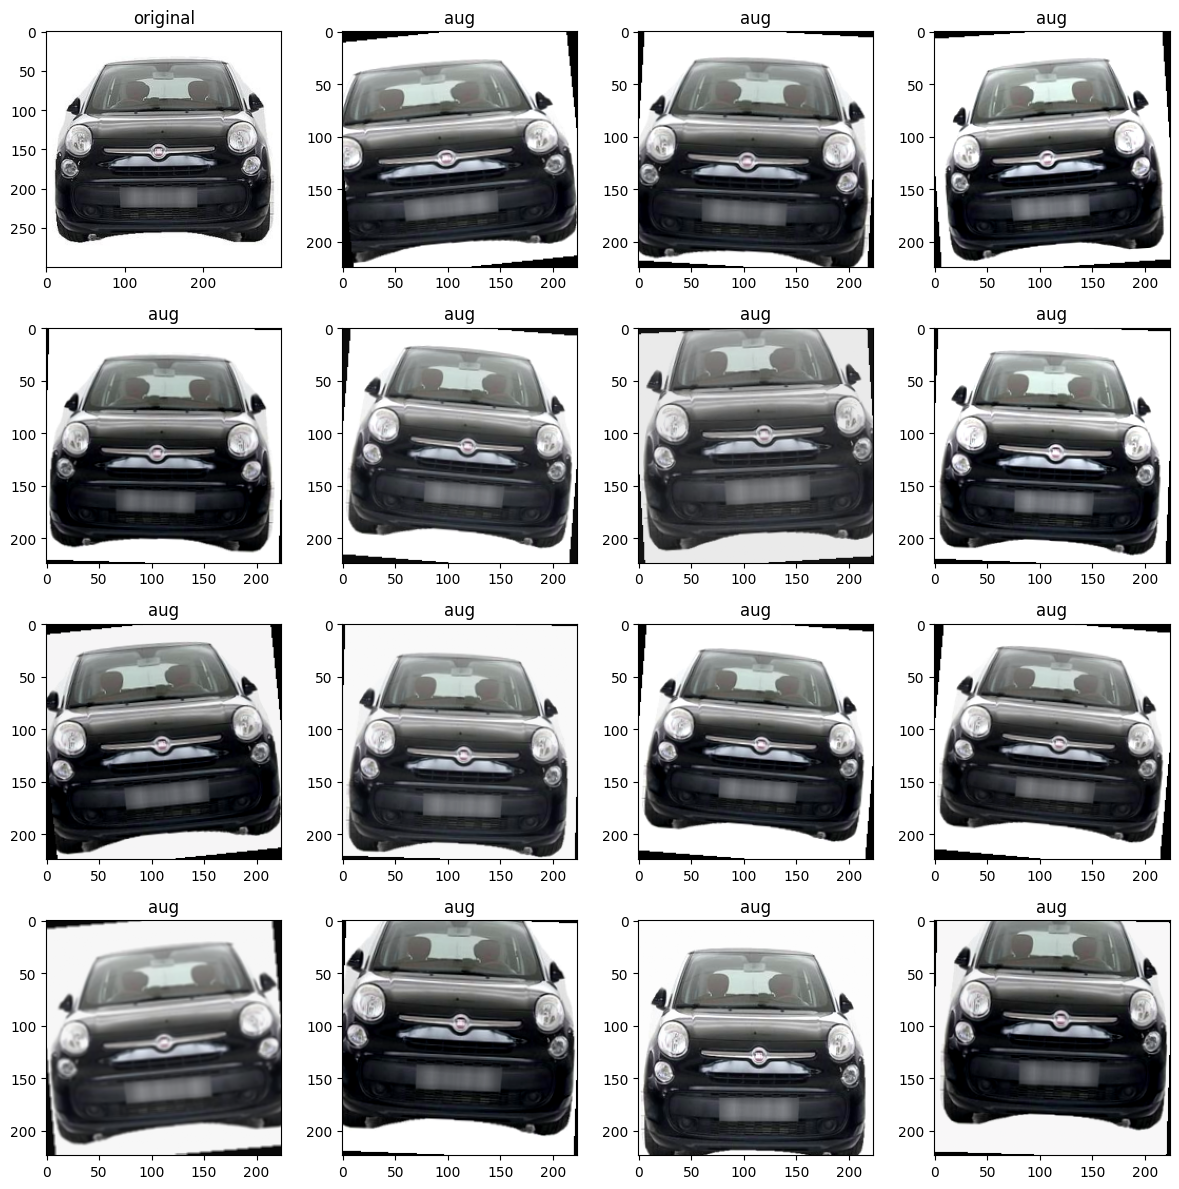

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def make_transforms(img_size: int, train: bool):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=7, interpolation=InterpolationMode.BILINEAR),
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.08, hue=0.0),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
            transforms.ToTensor(),

            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    return transforms.Compose([
        transforms.Resize(int(img_size * 1.15), interpolation=InterpolationMode.BILINEAR),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (x.cpu()*std + mean).clamp(0,1)

img_path = train_df.sample(1, random_state=SEED)["path"].iloc[0]
img = Image.open(img_path).convert("RGB")

tfm_train = make_transforms(224, train=True)

plt.figure(figsize=(12,12))
plt.subplot(4,4,1)
plt.imshow(img)
plt.title("original")

for i in range(2,17):
    x = tfm_train(img)
    plt.subplot(4,4,i)
    plt.imshow(denorm(x).permute(1,2,0))
    plt.title("aug")

plt.tight_layout()
plt.show()

## 6) Dataset, DataLoader

In [ ]:
class DVMDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tfm, return_path: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.tfm = tfm
        self.return_path = return_path

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfm(img)
        y = int(row["label"])
        if self.return_path:
            return x, y, row["path"]
        return x, y

def init_loaders(img_size: int, num_workers: int, batch_size: int = 64):
    counts = np.bincount(train_df["label"].values, minlength=n_classes)

    weights = 1.0 / np.maximum(counts, 1)
    sample_w = weights[train_df["label"].values]

    tr_loader = DataLoader(
        DVMDataset(train_df, make_transforms(img_size, True)),
        batch_size=batch_size,
        sampler=WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True),
        num_workers=num_workers
    )

    tr_eval_loader = DataLoader(
        DVMDataset(train_df, make_transforms(img_size, False)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    validation_loader = DataLoader(
        DVMDataset(val_df, make_transforms(img_size, False)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    test_loader = DataLoader(
        DVMDataset(test_df, make_transforms(img_size, False), return_path=True),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return tr_loader, tr_eval_loader, validation_loader, test_loader

IMG_SIZE = 224
BATCH_SIZE = 64

tr_loader, tr_eval_loader, validation_loader, test_loader = init_loaders(
    img_size=IMG_SIZE,
    num_workers=num_workers_default,
    batch_size=BATCH_SIZE,
)

batch = next(iter(tr_loader))
batch[0].shape, batch[1].shape


(torch.Size([64, 3, 224, 224]), torch.Size([64]))

### Пример одного элемента и одного батча

In [ ]:
sample_x, sample_y = tr_eval_loader.dataset[0]
print("One dataset item:")
print("type(sample_x):", type(sample_x))
print("sample_x.shape:", tuple(sample_x.shape))
print("sample_x.dtype:", sample_x.dtype)
print("sample_y:", sample_y)
print("type(sample_y):", type(sample_y))

batch = next(iter(tr_eval_loader))
batch_x, batch_y = unpack_batch(batch)

print("\nOne batch from DataLoader:")
print("type(batch_x):", type(batch_x))
print("batch_x.shape:", tuple(batch_x.shape))
print("batch_x.dtype:", batch_x.dtype)
print("type(batch_y):", type(batch_y))
print("batch_y.shape:", tuple(batch_y.shape))
print("batch_y.dtype:", batch_y.dtype)
print("first 8 labels in batch:", batch_y[:8].tolist())


## 7) Реализация обучения модели

In [ ]:
from typing import Optional


def unpack_batch(batch):
    if len(batch) == 2:
        return batch
    x, y, _ = batch
    return x, y


def to_device(*tensors):
    return [t.to(device, non_blocking=True) for t in tensors]


def compute_class_weights(labels, n_classes):
    counts = np.bincount(labels, minlength=n_classes)
    weights = counts.sum() / np.maximum(counts, 1)
    return torch.tensor(weights, dtype=torch.float32, device=device)


def clone_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


@torch.no_grad()
def eval_epoch(model, loader, max_batches: Optional[int] = None):
    model.eval()

    all_targets = []
    all_preds = []
    total_loss = 0.0
    total_samples = 0
    total_correct = 0

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x, y = unpack_batch(batch)
        x, y = to_device(x, y)


        logits = model(x)
        loss = F.cross_entropy(logits, y)

        batch_size = y.size(0)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * batch_size
        total_samples += batch_size
        total_correct += (preds == y).sum().item()

        all_targets.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    if total_samples == 0:
        return 0.0, 0.0, 0.0

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)

    avg_loss = total_loss / total_samples
    f1 = f1_score(y_true, y_pred, average="macro")
    acc = total_correct / total_samples
    return avg_loss, f1, acc


def train_model(
    model,
    tr_loader,
    tr_eval_loader,
    va_loader,
    epochs: int,
    lr: float,
    weight_decay: float = 1e-4,
    max_grad_norm: float = 1.0,
    label_smoothing: float = 0.0,
    mixed_precision: bool = True,
    train_metric_batches: int = 60,
):
    model = model.to(device)

    class_weights = compute_class_weights(train_df["label"].values, n_classes)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    use_amp = mixed_precision and use_amp_default
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        scaler = torch.amp.GradScaler(amp_device, enabled=use_amp)
        autocast_ctx = lambda: torch.amp.autocast(amp_device, enabled=use_amp)
    else:
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
        autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)

    best = {"f1": -1.0, "epoch": -1, "state": None}
    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_samples = 0

        pbar = tqdm(tr_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            x, y = unpack_batch(batch)
            x, y = to_device(x, y)

            optimizer.zero_grad(set_to_none=True)

            with autocast_ctx():
                logits = model(x)
                loss = F.cross_entropy(
                    logits,
                    y,
                    weight=class_weights,
                    label_smoothing=label_smoothing,
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            batch_size = y.size(0)
            train_loss_sum += loss.item() * batch_size
            train_samples += batch_size

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

        scheduler.step()

        train_loss = train_loss_sum / max(train_samples, 1)
        _, train_f1, train_acc = eval_epoch(model, tr_eval_loader, max_batches=train_metric_batches)
        val_loss, val_f1, val_acc = eval_epoch(model, va_loader)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_f1_macro": train_f1,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_f1_macro": val_f1,
                "val_acc": val_acc,
            }
        )

        if val_f1 > best["f1"]:
            best["f1"] = val_f1
            best["epoch"] = epoch
            best["state"] = clone_state_dict(model)

        print(
            f"[{epoch:02d}/{epochs:02d}] "
            f"train_loss={train_loss:.4f} "
            f"train_f1={train_f1:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_f1={val_f1:.4f} "
            f"best_val_f1={best['f1']:.4f} (epoch {best['epoch']})"
        )

    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


def plot_history(hist: pd.DataFrame, title: str):
    plots = [
        ("loss", "train_loss", "val_loss"),
        ("F1_macro", "train_f1_macro", "val_f1_macro"),
    ]

    for metric_name, train_col, val_col in plots:
        plt.figure(figsize=(8, 4))
        plt.plot(hist["epoch"], hist[train_col], label=train_col)
        plt.plot(hist["epoch"], hist[val_col], label=val_col)
        plt.title(f"{title} — {metric_name}")
        plt.xlabel("epoch")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 7) Самописная модель - ResNet18


In [ ]:

class ResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.down = None
        if stride != 1 or in_ch != out_ch:
            self.down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        if self.down is not None:
            identity = self.down(identity)
        out = F.relu(out + identity, inplace=True)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes):
        super().__init__()
        self.in_ch = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _make_layer(self, block, out_ch, blocks, stride):
        layers = [block(self.in_ch, out_ch, stride=stride)]
        self.in_ch = out_ch
        for _ in range(1, blocks):
            layers.append(block(self.in_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.fc(x)
        return x

def resnet18_custom(num_classes: int):
    return ResNet(ResNetBlock, [2, 2, 2, 2], num_classes=num_classes)

scratch_model = resnet18_custom(n_classes)
sum(p.numel() for p in scratch_model.parameters()) / 1e6

11.181642

epoch 1/15:   0%|          | 0/732 [00:00<?, ?it/s]

[01/15] train_loss=0.7344 train_f1=0.4066 val_loss=1.8044 val_f1=0.4014 best_val_f1=0.4014 (epoch 1)


epoch 2/15:   0%|          | 0/732 [00:00<?, ?it/s]

[02/15] train_loss=0.5078 train_f1=0.3804 val_loss=2.0845 val_f1=0.3777 best_val_f1=0.4014 (epoch 1)


epoch 3/15:   0%|          | 0/732 [00:00<?, ?it/s]

...

[13/15] train_loss=0.0486 train_f1=0.8530 val_loss=0.4880 val_f1=0.8008 best_val_f1=0.8008 (epoch 13)


epoch 14/15:   0%|          | 0/732 [00:00<?, ?it/s]

[14/15] train_loss=0.0441 train_f1=0.8788 val_loss=0.4611 val_f1=0.8185 best_val_f1=0.8185 (epoch 14)


epoch 15/15:   0%|          | 0/732 [00:00<?, ?it/s]

[15/15] train_loss=0.0424 train_f1=0.8694 val_loss=0.4587 val_f1=0.8171 best_val_f1=0.8185 (epoch 14)

Model: custom_resnet18
Best epoch: 14
Best val_f1_macro: 0.8185
Training time: 19.15 min


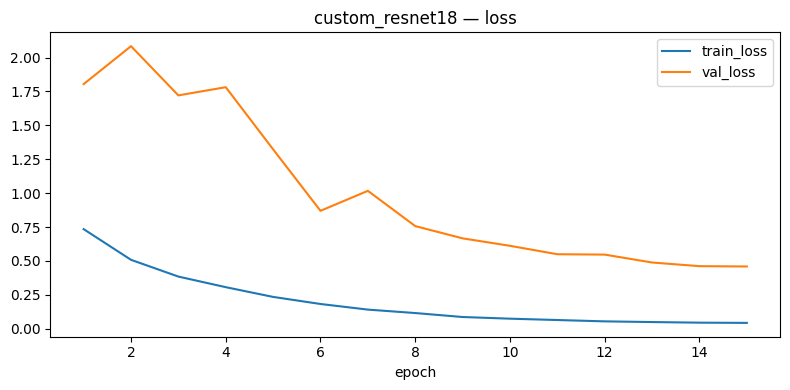

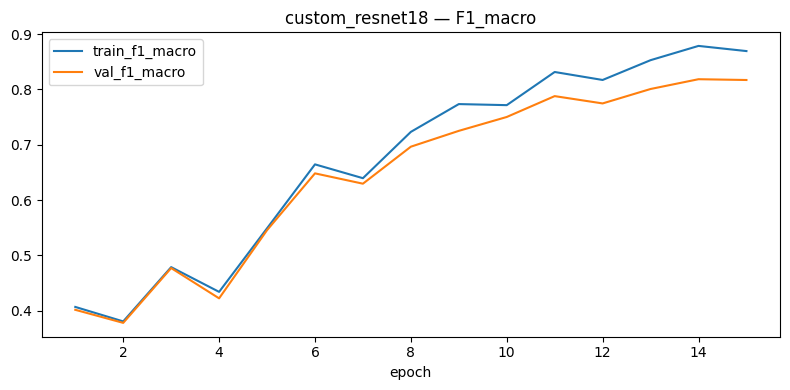

In [15]:

def print_training_summary(model_name: str, best_info: dict, elapsed_sec: float):
    print(
        f"\n{'=' * 60}\n"
        f"Model: {model_name}\n"
        f"Best epoch: {best_info['epoch']}\n"
        f"Best val_f1_macro: {best_info['f1']:.4f}\n"
        f"Training time: {elapsed_sec / 60:.2f} min\n"
        f"{'=' * 60}"
    )

def print_test_summary(model_name: str, te_loss: float, te_f1: float, te_acc: float):
    print(
        f"\n{'-' * 60}\n"
        f"Test summary: {model_name}\n"
        f"loss={te_loss:.4f} | f1_macro={te_f1:.4f} | acc={te_acc:.4f}\n"
        f"{'-' * 60}"
    )

t0 = time.time()
scratch_model, scratch_hist, scratch_best = train_model(
    scratch_model, tr_loader, tr_eval_loader, validation_loader,
    epochs=15,
    lr=3e-4,
    weight_decay=1e-4,
    label_smoothing=0.0,
    mixed_precision=True,
)
t1 = time.time()

print_training_summary("custom_resnet18", scratch_best, t1 - t0)

plot_history(scratch_hist, "custom_resnet18")


In [16]:
te_loss, te_f1, te_acc = eval_epoch(scratch_model, test_loader)
print_test_summary("custom_resnet18", te_loss, te_f1, te_acc)



------------------------------------------------------------
Test summary: custom_resnet18
loss=0.4807 | f1_macro=0.8095 | acc=0.8560
------------------------------------------------------------


## 8) Модель №2: ResNet50 pretrained (ImageNet) → fine-tune

In [17]:
def build_resnet50_pretrained(num_classes: int):
    model = torchvision.models.resnet50(
        weights=torchvision.models.ResNet50_Weights.DEFAULT
    )
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    n_params_m = sum(p.numel() for p in model.parameters()) / 1e6
    return model, n_params_m


resnet50_model, resnet50_params_m = build_resnet50_pretrained(n_classes)
resnet50_params_m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


23.528522

epoch 1/2:   0%|          | 0/732 [00:00<?, ?it/s]

[01/02] train_loss=0.6636 train_f1=0.4746 val_loss=1.4292 val_f1=0.4788 best_val_f1=0.4788 (epoch 1)


epoch 2/2:   0%|          | 0/732 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[02/02] train_loss=0.4698 train_f1=0.4866 val_loss=1.4735 val_f1=0.4786 best_val_f1=0.4788 (epoch 1)


...

epoch 5/6:   0%|          | 0/732 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  ^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    if w.is_alive():^^
^^  ^ ^ 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process' 
    ^ ^ ^ ^^ ^  ^ ^ ^ ^^^^^^^
  File "

[05/06] train_loss=0.0262 train_f1=0.9328 val_loss=0.3169 val_f1=0.8839 best_val_f1=0.8839 (epoch 5)


epoch 6/6:   0%|          | 0/732 [00:00<?, ?it/s]

[06/06] train_loss=0.0203 train_f1=0.9540 val_loss=0.2808 val_f1=0.8936 best_val_f1=0.8936 (epoch 6)

Model: resnet50_pretrained
Best epoch: 6
Best val_f1_macro: 0.8936
Training time: 10.66 min


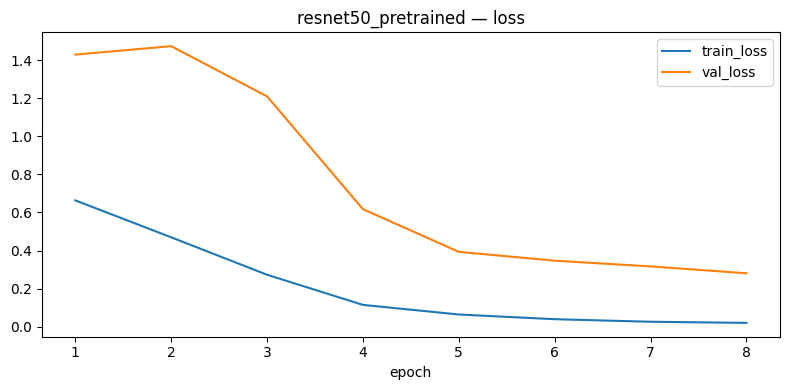

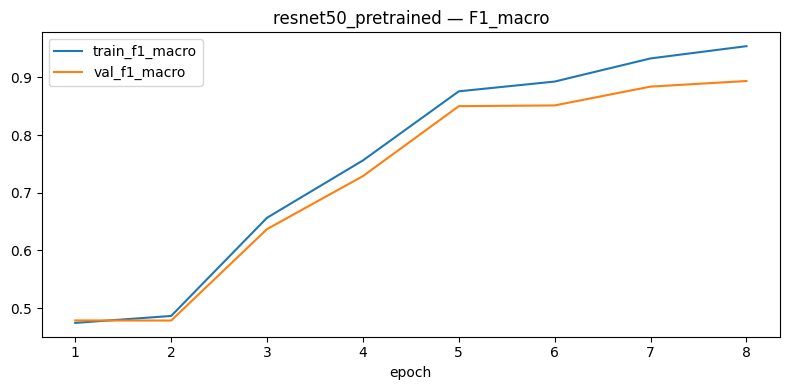

In [18]:
def set_resnet_trainable(model: nn.Module, train_backbone: bool):
    for name, param in model.named_parameters():
        is_head = name.startswith("fc.")
        param.requires_grad = is_head or train_backbone


def shift_history_epochs(history: pd.DataFrame, offset: int) -> pd.DataFrame:
    history = history.copy()
    history["epoch"] += offset
    return history


def finetune_resnet50(model):
    t0 = time.time()

    set_resnet_trainable(model, train_backbone=False)
    model, hist_stage_1, best_stage_1 = train_model(
        model,
        tr_loader,
        tr_eval_loader,
        validation_loader,
        epochs=2,
        lr=2e-3,
        weight_decay=1e-4,
        mixed_precision=True,
    )

    set_resnet_trainable(model, train_backbone=True)
    model, hist_stage_2, best_stage_2 = train_model(
        model,
        tr_loader,
        tr_eval_loader,
        validation_loader,
        epochs=6,
        lr=5e-4,
        weight_decay=1e-4,
        mixed_precision=True,
    )

    total_time = time.time() - t0
    full_history = pd.concat(
        [
            hist_stage_1,
            shift_history_epochs(hist_stage_2, hist_stage_1["epoch"].max()),
        ],
        ignore_index=True,
    )

    return model, full_history, best_stage_1, best_stage_2, total_time


resnet50_model, resnet50_hist, resnet50_best_1, resnet50_best_2, resnet50_time = finetune_resnet50(resnet50_model)

print_training_summary("resnet50_pretrained", resnet50_best_2, resnet50_time)
plot_history(resnet50_hist, "resnet50_pretrained")

In [19]:
te_loss, te_f1, te_acc = eval_epoch(resnet50_model, test_loader)
print_test_summary("resnet50_pretrained", te_loss, te_f1, te_acc)



------------------------------------------------------------
Test summary: resnet50_pretrained
loss=0.2914 | f1_macro=0.8899 | acc=0.9195
------------------------------------------------------------


## 9) Модель №3: MobileNetV3-Large pretrained (ImageNet) → fine-tune

In [20]:

def mobilenet_v3_large_pretrained(num_classes: int):
    m = torchvision.models.mobilenet_v3_large(weights=torchvision.models.MobileNet_V3_Large_Weights.DEFAULT)
    in_f = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(in_f, num_classes)
    return m

mobv3_model = mobilenet_v3_large_pretrained(n_classes)
sum(p.numel() for p in mobv3_model.parameters()) / 1e6


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 205MB/s]


4.214842

epoch 1/2:   0%|          | 0/732 [00:00<?, ?it/s]

[01/02] train_loss=0.5446 train_f1=0.4691 val_loss=1.7046 val_f1=0.4572 best_val_f1=0.4572 (epoch 1)


epoch 2/2:   0%|          | 0/732 [00:00<?, ?it/s]

[02/02] train_loss=0.2665 train_f1=0.5603 val_loss=1.2188 val_f1=0.5523 best_val_f1=0.5523 (epoch 2)


epoch 1/6:   0%|          | 0/732 [00:00<?, ?it/s]

...

epoch 5/6:   0%|          | 0/732 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2eba9b49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[05/06] train_loss=0.0237 train_f1=0.9220 val_loss=0.3193 val_f1=0.8748 best_val_f1=0.8755 (epoch 4)


epoch 6/6:   0%|          | 0/732 [00:00<?, ?it/s]

[06/06] train_loss=0.0194 train_f1=0.9604 val_loss=0.2794 val_f1=0.8909 best_val_f1=0.8909 (epoch 6)

Model: mobilenet_v3_large_pretrained
Best epoch: 6
Best val_f1_macro: 0.8909
Training time: 11.90 min


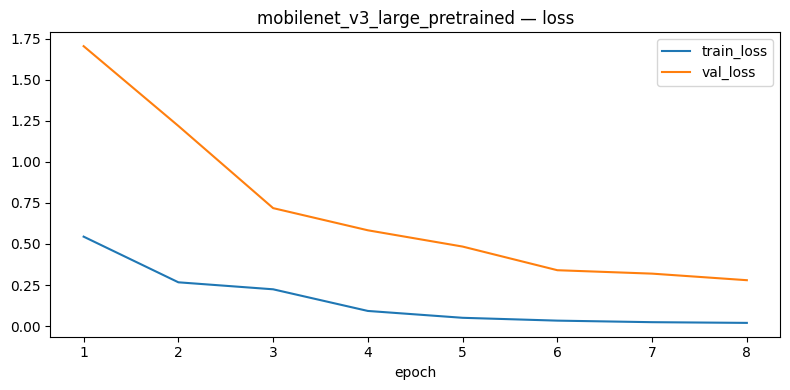

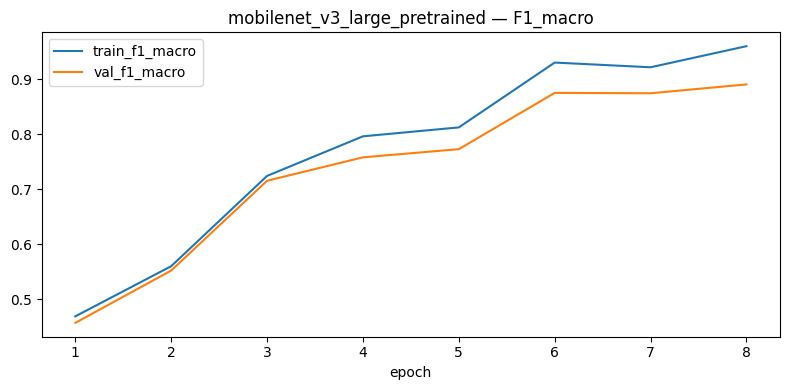

In [21]:

def freeze_backbone_mobv3(m: nn.Module, freeze: bool = True):
    for name, p in m.named_parameters():
        if name.startswith("classifier."):
            p.requires_grad = True
        else:
            p.requires_grad = (not freeze)

freeze_backbone_mobv3(mobv3_model, True)

t0 = time.time()
mobv3_model, mobv3_hist_1, mobv3_best_1 = train_model(
    mobv3_model, tr_loader, tr_eval_loader, validation_loader,
    epochs=2,
    lr=2e-3,
    weight_decay=1e-4,
    mixed_precision=True,
)

freeze_backbone_mobv3(mobv3_model, False)

mobv3_model, mobv3_hist_2, mobv3_best_2 = train_model(
    mobv3_model, tr_loader, tr_eval_loader, validation_loader,
    epochs=6,
    lr=6e-4,
    weight_decay=1e-4,
    mixed_precision=True,
)
t1 = time.time()

mobv3_hist = pd.concat([
    mobv3_hist_1,
    mobv3_hist_2.assign(epoch=mobv3_hist_2["epoch"] + mobv3_hist_1["epoch"].max()),
], ignore_index=True)

print_training_summary("mobilenet_v3_large_pretrained", mobv3_best_2, t1 - t0)
plot_history(mobv3_hist, "mobilenet_v3_large_pretrained")


In [22]:
te_loss, te_f1, te_acc = eval_epoch(mobv3_model, test_loader)
print_test_summary("mobilenet_v3_large_pretrained", te_loss, te_f1, te_acc)



------------------------------------------------------------
Test summary: mobilenet_v3_large_pretrained
loss=0.2856 | f1_macro=0.9021 | acc=0.9243
------------------------------------------------------------


## 10) Сравнение моделей + отчёт и вывод

In [23]:

@torch.no_grad()
def predict_labels(model, loader, max_batches=None):
    model.eval()
    ys, ps, paths = [], [], []
    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        if len(batch) == 2:
            x, y = batch
            pths = None
        else:
            x, y, pths = batch

        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()

        ys.append(y.numpy())
        ps.append(pred)
        if pths is not None:
            paths += list(pths)

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred, paths

def eval_all_splits(model):
    tr_loss, tr_f1, tr_acc = eval_epoch(model, tr_eval_loader)
    va_loss, va_f1, va_acc = eval_epoch(model, validation_loader)
    te_loss, te_f1, te_acc = eval_epoch(model, test_loader)
    return {
        "train_loss": tr_loss, "train_f1_macro": tr_f1, "train_acc": tr_acc,
        "val_loss": va_loss, "val_f1_macro": va_f1, "val_acc": va_acc,
        "test_loss": te_loss, "test_f1_macro": te_f1, "test_acc": te_acc,
    }

models = {
    "custom_resnet18": scratch_model,
    "resnet50_pretrained": resnet50_model,
    "mobilenet_v3_large_pretrained": mobv3_model,
}

results = []
test_preds = {}

for name, model in models.items():
    m = model.to(device)
    metrics = eval_all_splits(m)
    metrics["model"] = name
    results.append(metrics)

    y_true, y_pred, paths = predict_labels(m, test_loader)
    test_preds[name] = (y_true, y_pred, paths)

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
display(results_df)

print("\nТребование: F1_macro > 0.8 на test (у лучшей модели)")
print("best test_f1_macro:", results_df.iloc[0]["test_f1_macro"])


,train_loss,train_f1_macro,train_acc,val_loss,val_f1_macro,val_acc,test_loss,test_f1_macro,test_acc,model
0,0.138726,0.962191,0.955910,0.279379,0.890883,0.924432,0.285600,0.902095,0.924261,mobilenet_v3_large_pretrained
1,0.153676,0.957456,0.952640,0.280819,0.893648,0.922722,0.291391,0.889876,0.919473,resnet50_pretrained
2,0.342180,0.883086,0.886239,0.461070,0.818533,0.863566,0.480702,0.809473,0.856044,custom_resnet18



Требование: F1_macro > 0.8 на test (у лучшей модели)
best test_f1_macro: 0.9020946565722475


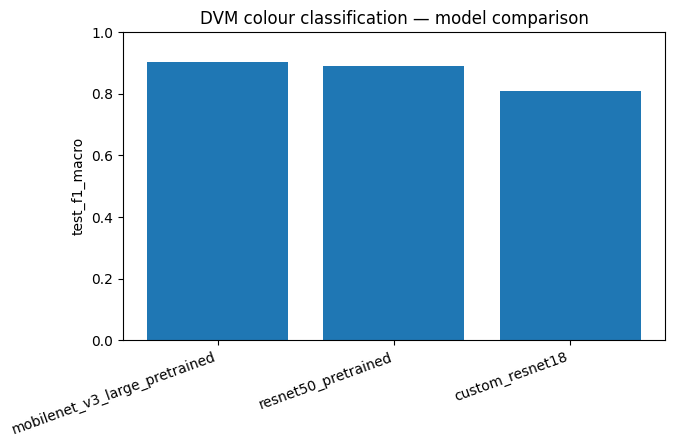


Best overall model: mobilenet_v3_large_pretrained
test_f1_macro: 0.9021


In [24]:
metric_col = "test_f1_macro"
if metric_col not in results_df.columns:
    metric_col = next((c for c in ["f1_macro_test", "f1_macro", "test_f1", "f1_test"] if c in results_df.columns), None)
if metric_col is None:
    raise KeyError(f"Не нашёл колонку с macro-F1. Колонки: {list(results_df.columns)}")

plot_df = results_df.sort_values(metric_col, ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
plt.bar(plot_df["model"], plot_df[metric_col])
plt.ylim(0, 1.0)
plt.ylabel(f"{metric_col}")
plt.xticks(rotation=20, ha="right")
plt.title("DVM colour classification — model comparison")
plt.show()

best_f1 = float(plot_df.loc[0, metric_col])
best_model = plot_df.loc[0, "model"]
print(
    f"\n{'=' * 60}\n"
    f"Best overall model: {best_model}\n"
    f"{metric_col}: {best_f1:.4f}\n"
    f"{'=' * 60}"
)

MODEL: mobilenet_v3_large_pretrained
Test metrics: f1_macro= 0.9020946565722475 acc= 0.9242605573602325

Classification report (test):
              precision    recall  f1-score   support

       beige     0.8448    0.8167    0.8305        60
       black     0.9302    0.9309    0.9305      1432
        blue     0.9251    0.9164    0.9207       849
       brown     0.7647    0.8571    0.8083        91
       green     0.8421    0.8312    0.8366        77
        grey     0.8801    0.8439    0.8616       948
         red     0.9934    0.9852    0.9893       609
      silver     0.8911    0.9266    0.9085       777
       white     0.9654    0.9808    0.9731       939
      yellow     0.9844    0.9403    0.9618        67

    accuracy                         0.9243      5849
   macro avg     0.9021    0.9029    0.9021      5849
weighted avg     0.9244    0.9243    0.9242      5849



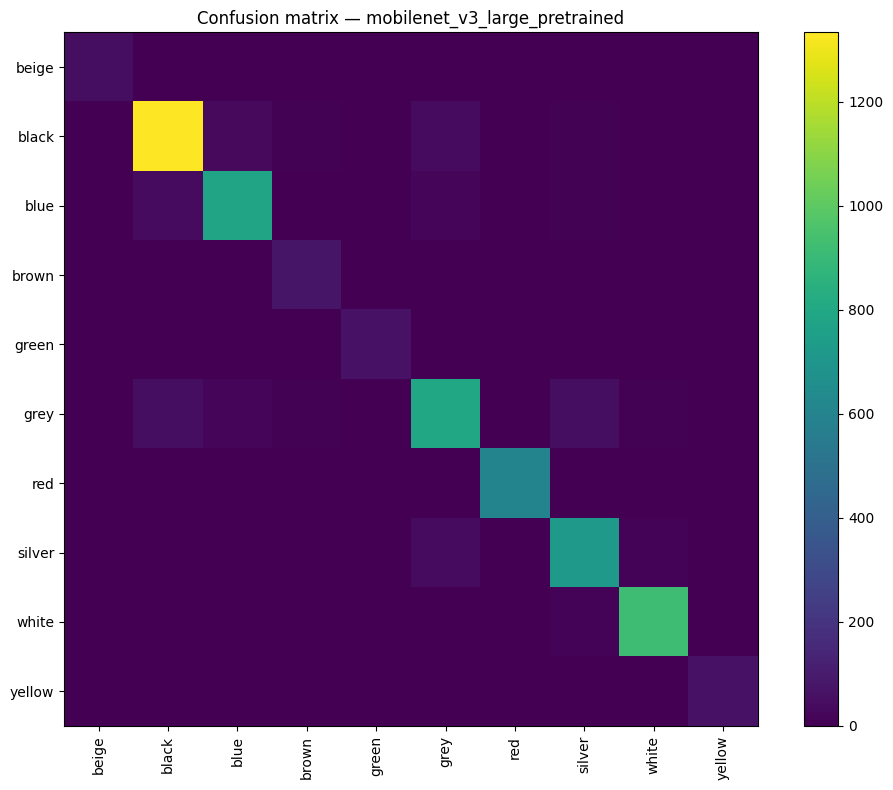

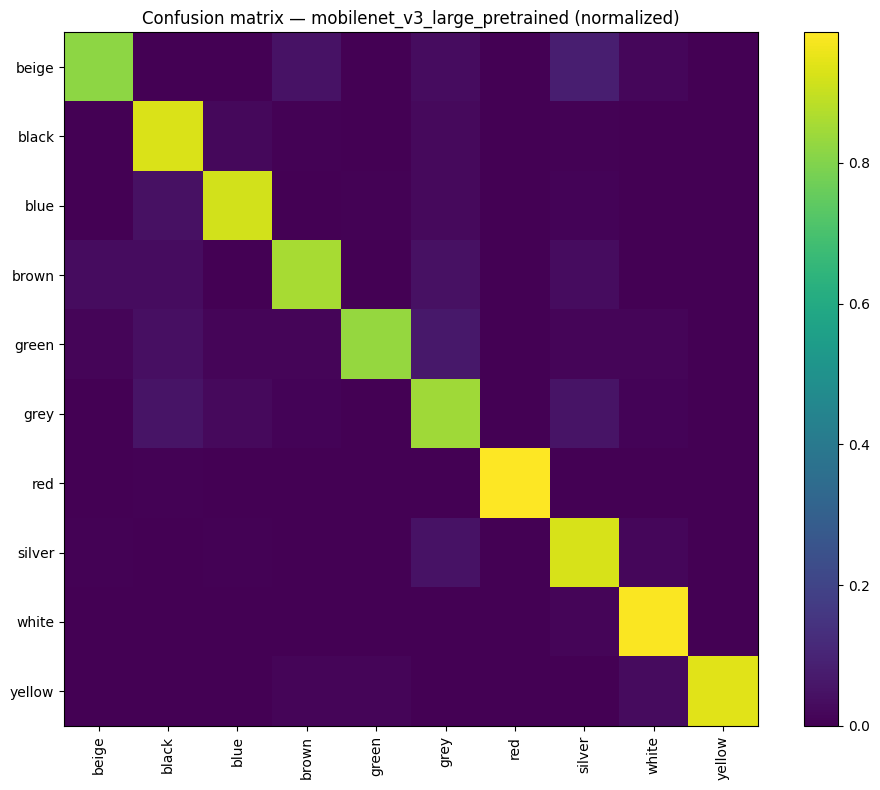

MODEL: resnet50_pretrained
Test metrics: f1_macro= 0.8898761449088255 acc= 0.9194734142588477

Classification report (test):
              precision    recall  f1-score   support

       beige     0.7719    0.7333    0.7521        60
       black     0.9362    0.9218    0.9289      1432
        blue     0.8807    0.9388    0.9088       849
       brown     0.7018    0.8791    0.7805        91
       green     0.7857    0.8571    0.8199        77
        grey     0.8858    0.8186    0.8509       948
         red     0.9917    0.9869    0.9893       609
      silver     0.8987    0.9138    0.9062       777
       white     0.9766    0.9776    0.9771       939
      yellow     0.9851    0.9851    0.9851        67

    accuracy                         0.9195      5849
   macro avg     0.8814    0.9012    0.8899      5849
weighted avg     0.9205    0.9195    0.9194      5849



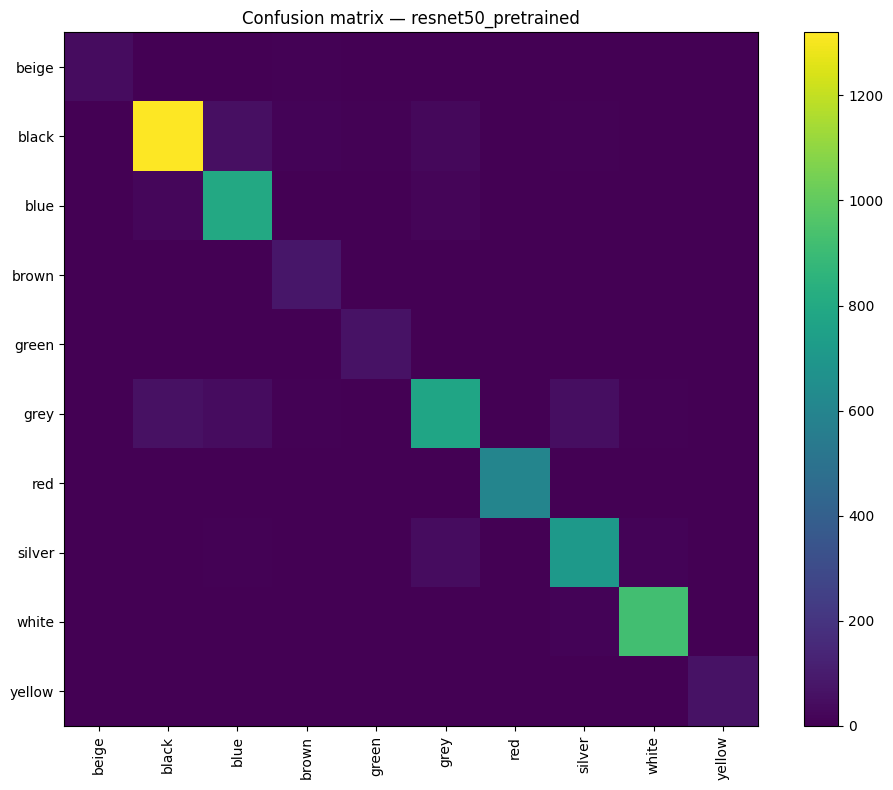

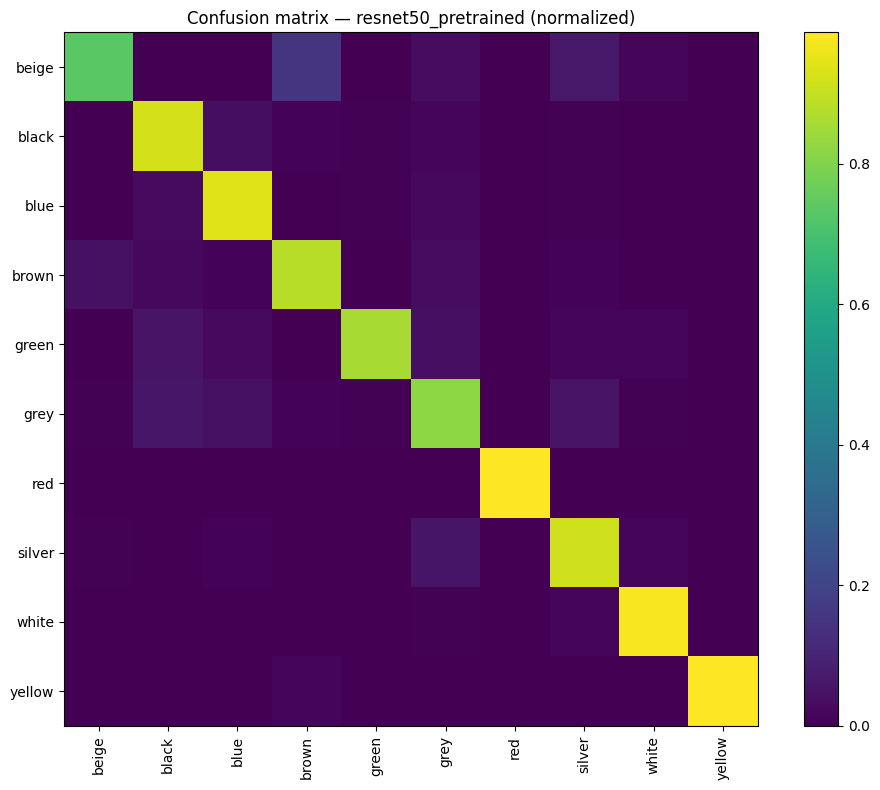

MODEL: custom_resnet18
Test metrics: f1_macro= 0.8094732714037665 acc= 0.8560437681654984

Classification report (test):
              precision    recall  f1-score   support

       beige     0.4737    0.7500    0.5806        60
       black     0.9263    0.8080    0.8631      1432
        blue     0.8409    0.8905    0.8650       849
       brown     0.4663    0.8352    0.5984        91
       green     0.6354    0.7922    0.7052        77
        grey     0.7562    0.7363    0.7461       948
         red     0.9851    0.9803    0.9827       609
      silver     0.8036    0.8687    0.8349       777
       white     0.9637    0.9329    0.9481       939
      yellow     0.9565    0.9851    0.9706        67

    accuracy                         0.8560      5849
   macro avg     0.7808    0.8579    0.8095      5849
weighted avg     0.8669    0.8560    0.8589      5849



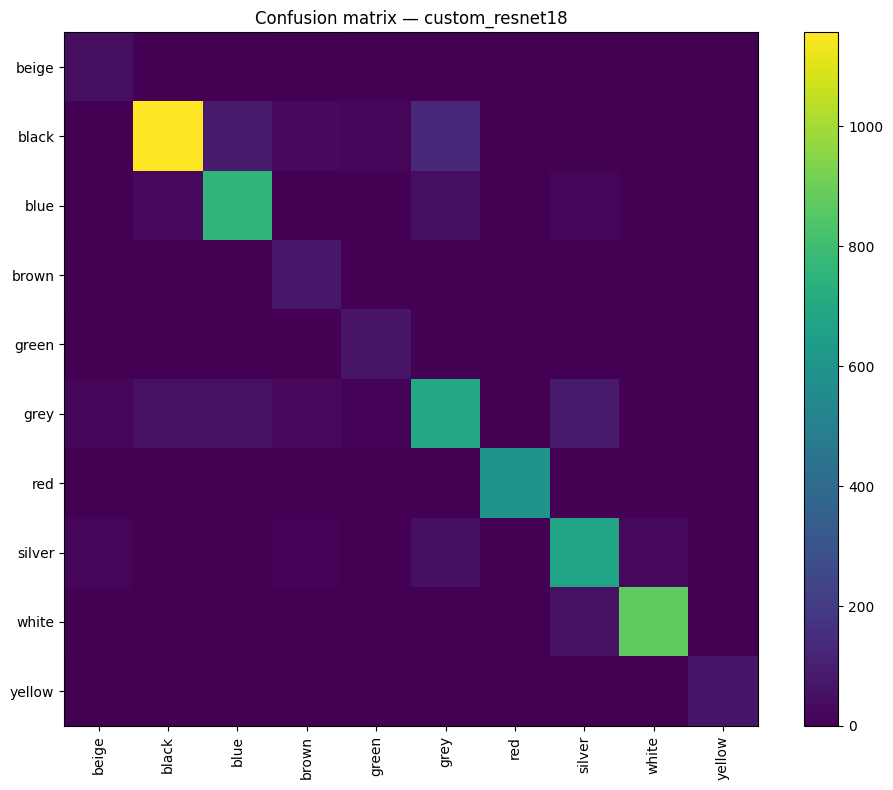

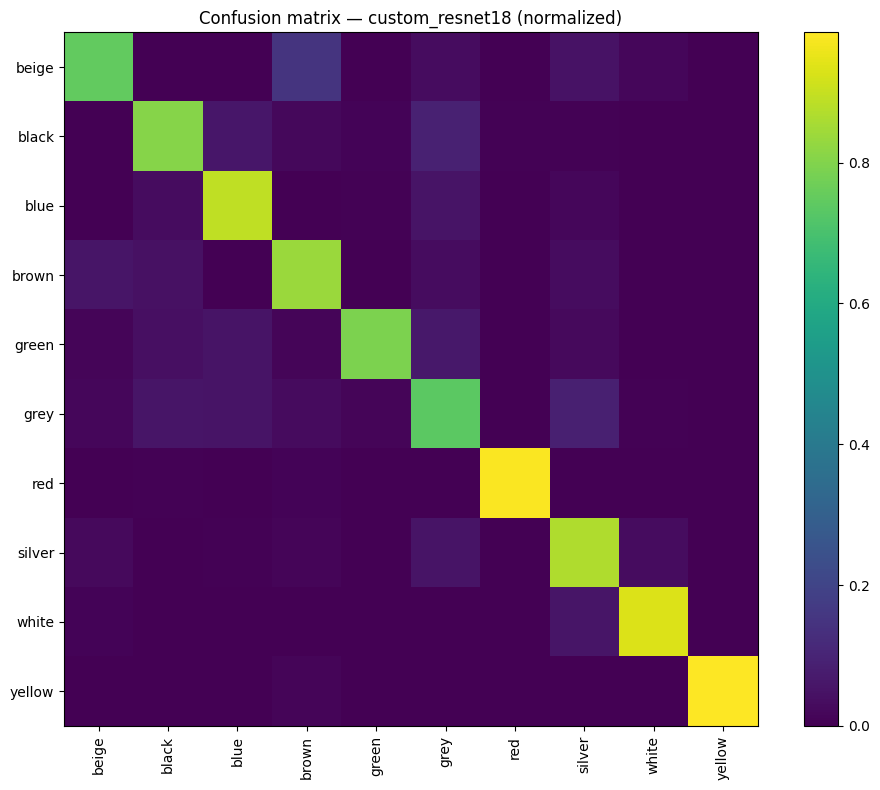

In [25]:
def plot_cm(cm, labels, title: str, normalize: bool = False):
    if normalize:
        cm = cm.astype(np.float32)
        cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(10,8))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title + (" (normalized)" if normalize else ""))
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

labels = [id2colour[i] for i in range(n_classes)]

for name in results_df["model"].tolist():
    y_true, y_pred, _ = test_preds[name]
    print("="*90)
    print("MODEL:", name)
    print("Test metrics:",
          "f1_macro=", f1_score(y_true, y_pred, average="macro"),
          "acc=", (y_true == y_pred).mean())
    print("\nClassification report (test):")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    plot_cm(cm, labels, f"Confusion matrix — {name}", normalize=False)
    plot_cm(cm, labels, f"Confusion matrix — {name}", normalize=True)


Best model by test_f1_macro: mobilenet_v3_large_pretrained


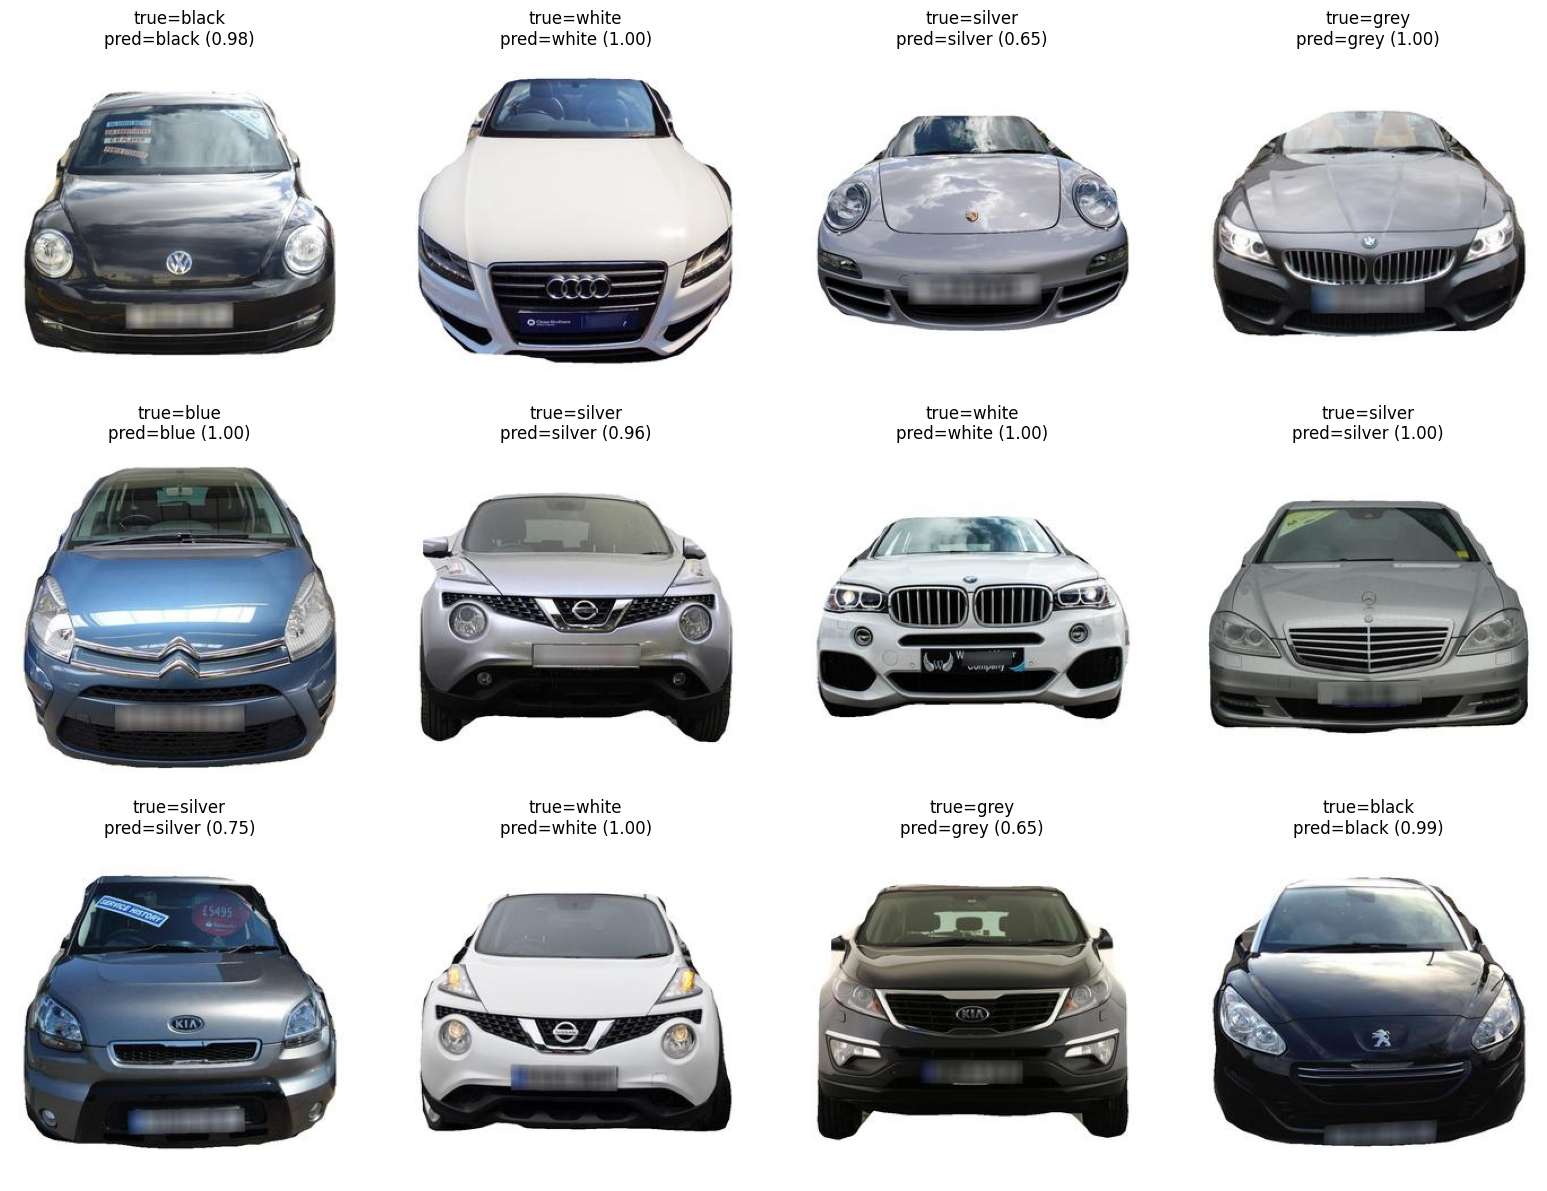

In [26]:

best_name = results_df.iloc[0]["model"]
best_model = models[best_name].to(device).eval()
print("Best model by test_f1_macro:", best_name)

eval_tfm = make_transforms(224, train=False)

@torch.no_grad()
def predict_one(path: str):
    img = Image.open(path).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(device)
    logits = best_model(x)
    prob = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred = int(prob.argmax())
    return pred, float(prob[pred])

def show_inference(frame: pd.DataFrame, n: int = 12):
    sample = frame.sample(n=min(n, len(frame)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(cols*4, rows*4))
    for i, r in sample.iterrows():
        path = r["path"]
        true = int(r["label"])
        pred, p = predict_one(path)

        img = Image.open(path).convert("RGB")
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"true={id2colour[true]}\npred={id2colour[pred]} ({p:.2f})")
    plt.tight_layout()
    plt.show()

show_inference(test_df, n=12)


### Вывод

- Мы обучили **3 модели** (1 from-scratch + 2 pretrained) на одинаковом **train/val/test** распределении цветов.
- Лучшей моделью по **test F1_macro** оказалась: **mobilenet_v3_large_pretrained*.

**Анализ ошибок:**
- По confusion matrix видно, какие цвета путаются чаще всего (например, `Gray`↔`Silver`, `Blue`↔`Black` при тёмном освещении).
- Именно поэтому мы используем умеренный `ColorJitter` (без hue), чтобы модель была устойчивее к освещению, но не “училась на перекрашивании”.

